# LDA
* Vectorization with BoW
* LDA algorithm
* Evaluation with perplexity and coherence
* Visualization with PCA & UMAP <br>
--> Present topic clusters and top words for optimal k

In [1]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import CountVectorizer

from sklearn.decomposition import LatentDirichletAllocation
from gensim.models import CoherenceModel
from gensim import corpora
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.decomposition import PCA
import umap.umap_ as umap
from sklearn.preprocessing import normalize

import pyLDAvis
import pyLDAvis.lda_model

In [2]:
df = pd.read_pickle("data/preprocessed_data.pkl")
df.head(5)

,id,author,question,link_flair_css_class,link_flair_text,description,created_utc,year,retrieved_on,org_post,language,clean_question,clean_desc,question_tokens,desc_tokens,q_tuple,d_tuple,post_tokens,clean_text
0,421zyl,[deleted],How is time defined at the big bang?,physics,Physics,[removed],2016-01-21 20:58:09,2016,2016-02-09 12:21:05,How is time defined at the big bang? [removed],en,how is time defined at the big bang,removed,"[time, define, big, bang]",[],"(time, define, big, bang)",(),"[time, define, big_bang]",time define big_bang
1,4r857d,[deleted],UFO best scientific explanation. Atmospherical...,geo,Earth Sciences,[removed],2016-07-04 17:05:51,2016,2016-09-03 18:04:14,UFO best scientific explanation. Atmospherical...,en,ufo best scientific explanation atmospherical ...,removed,"[ufo, good, scientific, explanation, atmospher...",[],"(ufo, good, scientific, explanation, atmospher...",(),"[ufo, good, scientific_explanation, atmospheri...",ufo good scientific_explanation atmospherical ...
2,4r0zwj,De_La_Soul_,It's a commonly known fact that metals oxidize...,chem,Chemistry,,2016-07-03 06:40:06,2016,2016-09-02 17:31:58,It's a commonly known fact that metals oxidize...,en,it s a commonly known fact that metals oxidize...,,"[s, commonly, know, fact, metal, oxidize, poss...",[],"(s, commonly, know, fact, metal, oxidize, poss...",(),"[s, commonly, know, fact, metal, oxidize, poss...",s commonly know fact metal oxidize possible di...
3,540ohz,MacShakeIt,"China builds large telescope, but i have a que...",astro,Astronomy,[removed],2016-09-22 19:17:55,2016,2016-10-14 11:02:04,"China builds large telescope, but i have a que...",en,china builds large telescope but i have a ques...,removed,"[china, build, large, telescope, question]",[],"(china, build, large, telescope, question)",(),"[china, build, large, telescope, question]",china build large telescope question
4,4r191k,[deleted],Geoscientists: Is there any current research i...,geo,Planetary Sci.,[removed],2016-07-03 08:26:38,2016,2016-09-02 17:34:09,Geoscientists: Is there any current research i...,en,geoscientists is there any current research in...,removed,"[geoscientist, current, research, project, sho...",[],"(geoscientist, current, research, project, sho...",(),"[geoscientist, current, research_project, shor...",geoscientist current research_project shortfal...


In [3]:
# Vectorization (BoW)
vectorizer = CountVectorizer(
    max_features=10000,
    min_df=5,
    max_df=0.8,
    ngram_range=(1, 1)
)
X = vectorizer.fit_transform(df['clean_text'])

# Vocabulary size
print(len(vectorizer.vocabulary_))
# Feature names
print(vectorizer.get_feature_names_out())
# Sparse feature matrix
print(X)

10000
['00' '00_00' '00_year' ... 'zoology' 'zoom' 'zygote']
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 3619007 stored elements and shape (591178, 10000)>
  Coords	Values
  (0, 9134)	1
  (0, 2482)	1
  (0, 1080)	1
  (1, 9367)	1
  (1, 4086)	1
  (1, 7909)	1
  (1, 3277)	1
  (1, 5745)	1
  (2, 1924)	1
  (2, 5128)	1
  (2, 3454)	1
  (2, 5735)	1
  (2, 6482)	1
  (2, 6945)	1
  (2, 3931)	1
  (3, 1701)	1
  (3, 1368)	1
  (3, 5171)	1
  (3, 8982)	1
  (3, 7284)	1
  (4, 2336)	1
  (4, 7619)	1
  (4, 5092)	1
  (4, 5820)	1
  (4, 3069)	1
  :	:
  (591173, 7284)	1
  (591173, 9568)	1
  (591173, 7711)	1
  (591173, 4018)	1
  (591173, 7046)	1
  (591173, 663)	1
  (591173, 466)	1
  (591173, 2530)	2
  (591173, 5949)	1
  (591173, 442)	1
  (591174, 3305)	1
  (591174, 2035)	1
  (591175, 9134)	1
  (591175, 2829)	1
  (591176, 3428)	1
  (591176, 5325)	1
  (591176, 297)	1
  (591176, 6528)	1
  (591176, 1759)	1
  (591176, 4451)	1
  (591176, 9224)	1
  (591177, 2945)	1
  (591177, 8008)	1
  (591177, 6768)	1
  (5

## LDA

### Finding the Best Value for *k*

In [4]:
dictionary = corpora.Dictionary(df['post_tokens'])

def train_lda(k, X):
    lda = LatentDirichletAllocation(
        n_components=k,
        learning_method="online",
        max_iter=10,
        random_state=42,
        n_jobs=-1,
        batch_size=32768,
        evaluate_every=-1
    )
    lda.fit(X)
    return lda

In [5]:
def evaluate_model(lda, X, vectorizer, texts, dictionary, top_n=10):

    # Perplexity
    perplexity = lda.perplexity(X)

    # Extract topics
    feature_names = np.array(vectorizer.get_feature_names_out())

    topics = []

    for topic in lda.components_:
        top_words = feature_names[topic.argsort()[-top_n:]]
        topics.append(list(top_words))

    # Coherence
    cm = CoherenceModel(
        topics=topics,
        texts=texts,
        dictionary=dictionary,
        coherence="c_v"
    )

    coherence = cm.get_coherence()

    # Topic diversity
    all_topic_words = []

    for topic in topics:
        all_topic_words.extend(topic)

    diversity = len(set(all_topic_words)) / len(all_topic_words)

    return coherence, perplexity, diversity

In [ ]:
def plot_lda_metrics(
    results,
    k_min,
    k_max,
    step,
    coherence_weight=0.5,
    perplexity_weight=0.3,
    diversity_weight=0.2,
    vertical_line_k=None
):
    
    # Extract values from results
    k_vals = [r[0] for r in results]
    coherence = np.array([r[1] for r in results]).reshape(-1, 1)
    perplexity = np.array([r[2] for r in results]).reshape(-1, 1)
    diversity = np.array([r[3] for r in results]).reshape(-1, 1)

    # Build summary table
    summary = pd.DataFrame({
        'k': k_vals,
        'Coherence': coherence.flatten(),
        'Diversity': diversity.flatten(),
        'Perplexity': perplexity.flatten()
    })

    # Normalize metrics
    scaler = MinMaxScaler()
    summary[['Coherence_norm', 'Diversity_norm', 'Perplexity_norm']] = scaler.fit_transform(
        summary[['Coherence', 'Diversity', 'Perplexity']]
    )

    # Invert perplexity
    summary['Perplexity_norm'] = 1 - summary['Perplexity_norm']

    # summary['Composite_Score'] = (
    #     coherence_weight * summary['Coherence_norm'] +
    #     diversity_weight * summary['Diversity_norm'] +
    #     perplexity_weight * summary['Perplexity_norm']
    # )

    # Print table with scores
    print(summary[['k', 'Coherence', 'Diversity', 'Perplexity', 'Coherence_norm', 'Diversity_norm', 'Perplexity_norm']])

    # Plot
    plt.figure(figsize=(10, 6))

    # Plot metrics
    plt.plot(k_vals, summary['Coherence_norm'], marker='o', label='Coherence')
    plt.plot(k_vals, summary['Perplexity_norm'], marker='s', label='Perplexity (inverted)')
    plt.plot(k_vals, summary['Diversity_norm'], marker='^', label='Topic Diversity')
    # plt.plot(k_vals, summary['Composite_Score'], marker='^', color='black', alpha=0.5, label='Combined Score')

    # Add vertical line if specified
    if vertical_line_k is not None:
        plt.axvline(x=vertical_line_k, color='black', linestyle='--', alpha=0.5, label=f'k={vertical_line_k}')

    # Labels and title
    plt.xlabel("Number of Topics (k)")
    plt.ylabel("Normalized Score")
    plt.title("LDA Model Evaluation")

    # Legend and grid
    plt.legend()
    plt.grid(visible=True)
    # plt.grid(visible=True, which='major', axis='x', linestyle='-', linewidth=0.5)
    plt.gca().xaxis.set_major_locator(plt.MultipleLocator(5))

    # Hide spines
    for spine in ['top', 'right', 'bottom', 'left']:
        plt.gca().spines[spine].set_visible(False)

    plt.tight_layout()

    # Save with hardcoded path and dpi
    plt.savefig(f'viz/LDA_evaluation_metrics-{k_min}-{k_max}-{step}.png', dpi=300)

    plt.show()

In [7]:
k_min = 2
k_max = 50
step = 1
k_values = range(k_min, k_max + 1, step)

results = []

for k in k_values:
    print(f"Training LDA with k={k}")

    lda = train_lda(k, X)

    coherence, perplexity, diversity = evaluate_model(
    lda, X, vectorizer, df['post_tokens'], dictionary
    )

    results.append((k, coherence, perplexity, diversity))

Training LDA with k=2
Training LDA with k=3
Training LDA with k=4
Training LDA with k=5
Training LDA with k=6
Training LDA with k=7
Training LDA with k=8
Training LDA with k=9
Training LDA with k=10
Training LDA with k=11
Training LDA with k=12
Training LDA with k=13
Training LDA with k=14
Training LDA with k=15
Training LDA with k=16
Training LDA with k=17
Training LDA with k=18
Training LDA with k=19
Training LDA with k=20
Training LDA with k=21
Training LDA with k=22
Training LDA with k=23
Training LDA with k=24
Training LDA with k=25
Training LDA with k=26
Training LDA with k=27
Training LDA with k=28
Training LDA with k=29
Training LDA with k=30
Training LDA with k=31
Training LDA with k=32
Training LDA with k=33
Training LDA with k=34
Training LDA with k=35
Training LDA with k=36
Training LDA with k=37
Training LDA with k=38
Training LDA with k=39
Training LDA with k=40
Training LDA with k=41
Training LDA with k=42
Training LDA with k=43
Training LDA with k=44
Training LDA with k

     k  Coherence  Diversity   Perplexity  Coherence_norm  Diversity_norm  \
0    2   0.458720   0.850000  2575.239636        0.000000        0.200935   
1    3   0.518039   0.900000  2554.770998        0.330731        0.562617   
2    4   0.582450   0.900000  2481.253894        0.689848        0.562617   
3    5   0.567337   0.860000  2460.435876        0.605588        0.273271   
4    6   0.607385   0.883333  2382.305112        0.828876        0.442056   
5    7   0.614687   0.885714  2404.128754        0.869584        0.459279   
6    8   0.638078   0.862500  2422.539759        1.000000        0.291355   
7    9   0.608027   0.822222  2487.306220        0.832455        0.000000   
8   10   0.589032   0.840000  2506.413265        0.726547        0.128598   
9   11   0.622672   0.881818  2519.856401        0.914106        0.431096   
10  12   0.616923   0.875000  2550.762272        0.882053        0.381776   
11  13   0.635836   0.876923  2521.027832        0.987504        0.395687   

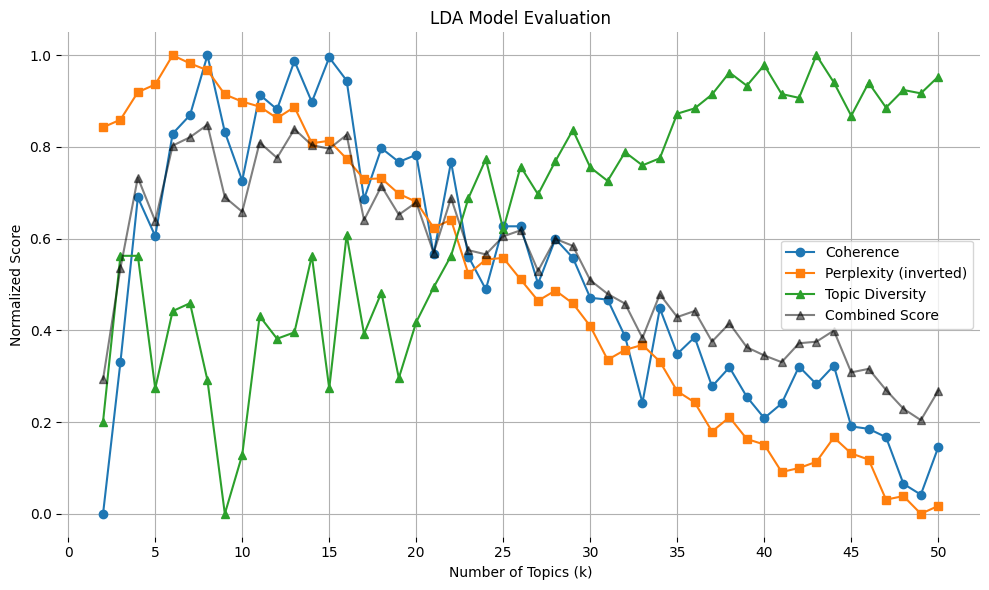

In [20]:
plot_lda_metrics(results, k_min=k_min, k_max=k_max, step=step)

From the broad overview it can be seen that the inverted perplexity score decreases constantly. The coherence score drops sharply right in the beginning and shows two smaller spikes at *k = 30* and *k = 60*. A higher coherence score is desirable for sematically meaniful topics which seems to be quite difficult here. As an additional metric topic diversity was plotted to measure the disctincness of topics. Unlike the coeherence score it rises rapidly with increasing *k* until its peak at *k = 50*. A good tradeoff between coherence and diversity seems to be in the range *k = 5* to *k = 35* which will be investigated with smaller steps in the following.

### Final Run with Best Values for *k*

In [35]:
def get_topic_labels(model, vectorizer, n_words=5, print_topics=False):
    """Get topic labels and optionally print them."""
    words = vectorizer.get_feature_names_out()
    topic_labels = {}

    for i, topic in enumerate(model.components_):
        top_words = [words[j] for j in topic.argsort()[-n_words:][::-1]]
        label = f"Topic {i}: " + " | ".join(top_words)
        topic_labels[i] = label
        if print_topics:
            print(f"Topic {i}: {top_words}")

    return topic_labels

In [ ]:
"""
def show_topics(model, vectorizer, n_words=10):
    words = vectorizer.get_feature_names_out()

    for i, topic in enumerate(model.components_):
        top_words = [words[j] for j in topic.argsort()[-n_words:]]
        print(f"Topic {i}: {top_words}")
"""

In [ ]:
"""
def get_topic_labels(model, vectorizer, n_words=5):
    words = vectorizer.get_feature_names_out()
    
    topic_labels = {}

    for i, topic in enumerate(model.components_):
        top_words = [words[j] for j in topic.argsort()[-n_words:][::-1]]
        topic_labels[i] = f"Topic {i}: " + " | ".join(top_words)

    return topic_labels
"""

In [ ]:
def plot_bars_topic_distribution(k):
    """
    Create a bar plot showing the distribution of documents across topics, with topic labels based on top words.
    """

    # Set default color if not provided
    color = plt.colormaps["tab20b"](0)

    # Create plot
    fig, ax = plt.subplots(figsize=(10, 6))

    sns.countplot(
        data=df,
        y="topic_label",
        order=df['topic_label'].value_counts().index,
        ax=ax,
        color=color
    )

    # Formatting
    ax.set_title(f"Publications by Topic (k={k})", fontsize=16)
    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.tick_params(axis='y', labelsize=11)
    ax.tick_params(axis='x', labelsize=11)

    ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

    # Hide spines
    for spine in ['top', 'right', 'bottom']:
        ax.spines[spine].set_visible(False)

    ax.grid(axis="y", visible=False)

    plt.tight_layout()

    # Save or show
    plt.savefig(f"viz/LDA_posts_per_topic_k{k}.png", dpi=300)
    plt.show()

In [ ]:
def plot_box_topic_confidence(k):
    """
    Plot boxplot of topic probabilities with top words as legend.
    """
    # Create plot
    fig, ax = plt.subplots(figsize=(10, 6))

    # Set default color if not provided
    color = plt.colormaps["tab20b"](16)

    # Boxplot
    sns.boxplot(
        data=df,
        x="topic",
        y="topic_prob",
        color=color,
        ax=ax
    )

    # Titles and labels
    ax.set_title("Topic Probability Distribution per Topic", fontsize=16)
    ax.set_xlabel("Topic", fontsize=12)
    ax.set_ylabel("Topic Confidence", fontsize=12)

    # Despine plot
    for spine in ['top', 'right', 'bottom']:
        ax.spines[spine].set_visible(False)

    fig.subplots_adjust(right=0.7)
    plt.tight_layout()
    plt.savefig(f"viz/LDA_topic_confidence_k{k}.png", dpi=300)
    plt.show()

Topic 0: ['people', 'cause', 'eye', 'like', 'look']
Topic 1: ['earth', 'planet', 'sun', 'moon', 'happen']
Topic 2: ['effect', 'use', 'high', 'increase', 'cause']
Topic 3: ['human', 'animal', 'body', 'brain', 'specie']
Topic 4: ['water', 'body', 'happen', 'temperature', 'food']
Topic 5: ['time', 'fast', 'speed', 'space', 'travel']
Topic 6: ['covid', 'science', 'vaccine', 'question', 'virus']
Topic 7: ['light', 'energy', 'universe', 'black_hole', 'mass']


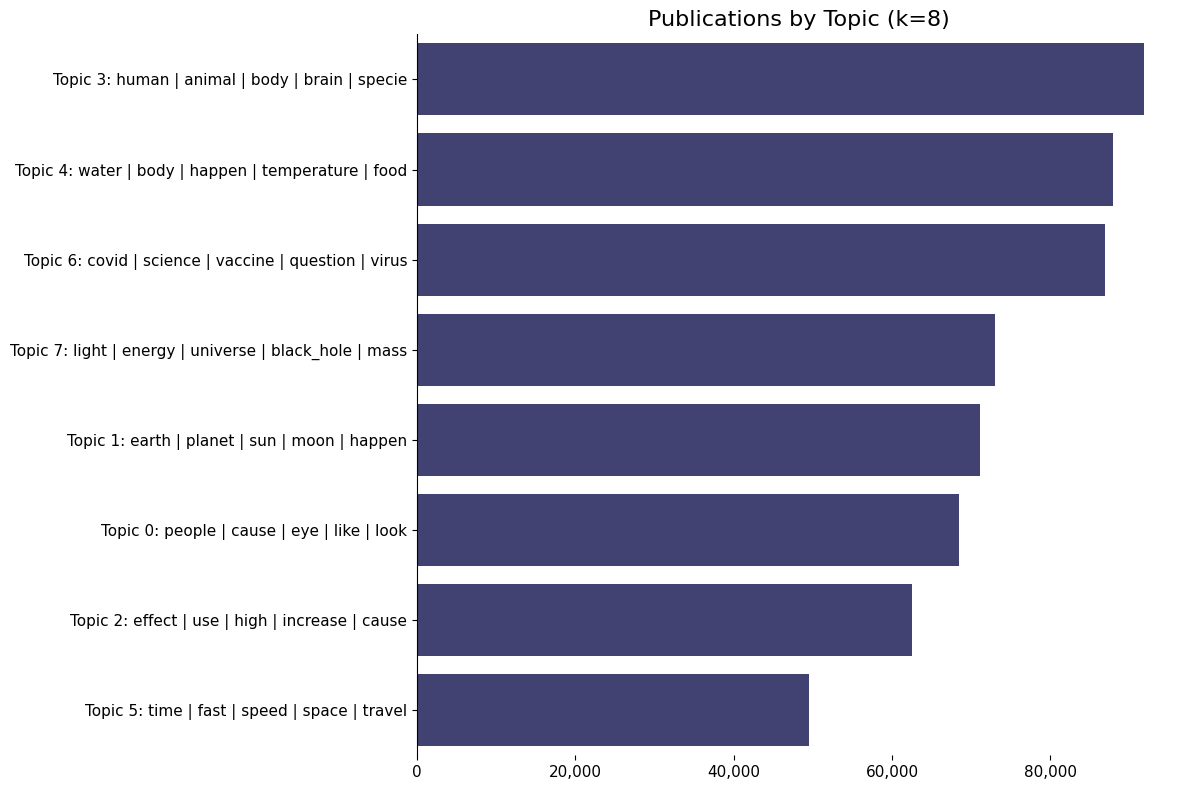

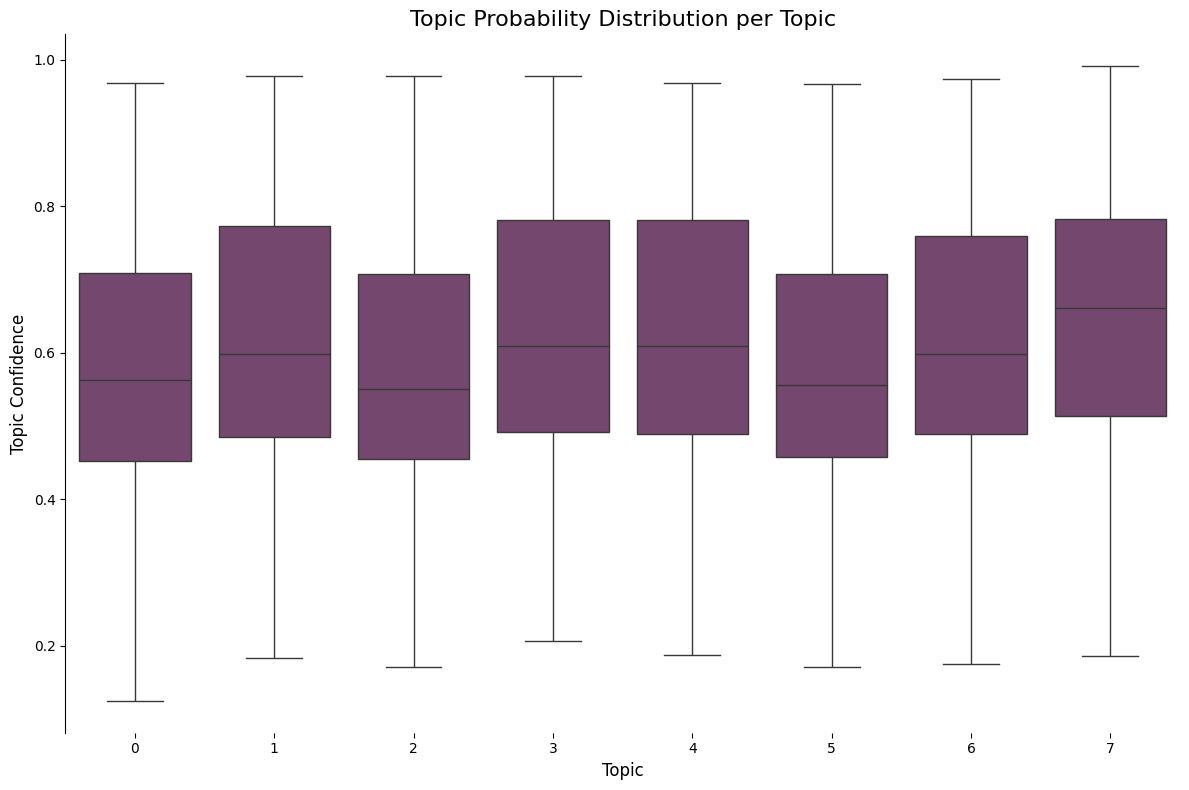

In [ ]:
k = 8
lda = train_lda(k, X)
doc_topics = lda.transform(X)

# Assign topics to documents
df["topic"] = doc_topics.argmax(axis=1)
df["topic_prob"] = doc_topics.max(axis=1)

# Get topic labels
topic_labels = get_topic_labels(lda, vectorizer)
# df["topic_label"] = df["topic"].map(topic_labels)

# Show topics
# show_topics(lda, vectorizer)

# Plot topic distribution
plot_bars_topic_distribution(model=lda, k=k)

# Plot topic confidence
plot_box_topic_confidence(k=k)

# pyLDAvis visualization
viz = pyLDAvis.lda_model.prepare(lda, X, vectorizer)
pyLDAvis.display(viz)

In [ ]:
k = 8

lda = train_lda(k, X)

doc_topics = lda.transform(X)

df["topic"] = doc_topics.argmax(axis=1)
df["topic_prob"] = doc_topics.max(axis=1)

topic_labels = get_topic_labels(lda, vectorizer)

df["topic_label"] = df["topic"].map(topic_labels)

show_topics(lda, vectorizer)

# Viz
viz = pyLDAvis.lda_model.prepare(lda, X, vectorizer)

pyLDAvis.display(viz)

Topic 0: ['thing', 'sound', 'light', 'person', 'color', 'look', 'like', 'eye', 'cause', 'people']
Topic 1: ['orbit', 'life', 'like', 'star', 'possible', 'happen', 'moon', 'sun', 'planet', 'earth']
Topic 2: ['climate_change', 'difference', 'affect', 'work', 'level', 'cause', 'increase', 'high', 'use', 'effect']
Topic 3: ['cell', 'possible', 'evolve', 'live', 'like', 'specie', 'brain', 'body', 'animal', 'human']
Topic 4: ['feel', 'heat', 'air', 'cold', 'eat', 'food', 'temperature', 'happen', 'body', 'water']
Topic 5: ['possible', 'slow', 'move', 'work', 'object', 'travel', 'space', 'speed', 'fast', 'time']
Topic 6: ['know', 'find', 'people', 'help', '19', 'virus', 'question', 'vaccine', 'science', 'covid']
Topic 7: ['gravity', 'exist', 'particle', 'matter', 'know', 'mass', 'black_hole', 'universe', 'energy', 'light']


In [22]:
k = 13

lda = train_lda(k, X)

doc_topics = lda.transform(X)

df["topic"] = doc_topics.argmax(axis=1)
df["topic_prob"] = doc_topics.max(axis=1)

topic_labels = get_topic_labels(lda, vectorizer)

df["topic_label"] = df["topic"].map(topic_labels)

show_topics(lda, vectorizer)

# Viz
viz = pyLDAvis.lda_model.prepare(lda, X, vectorizer)

pyLDAvis.display(viz)

Topic 0: ['thing', 'like', 'hear', 'different', 'color', 'light', 'look', 'eye', 'sound', 'people']
Topic 1: ['form', 'life', 'material', 'build', 'system', 'like', 'create', 'planet', 'star', 'possible']
Topic 2: ['climate_change', 'impact', 'affect', 'vs', 'man', 'level', 'cause', 'increase', 'high', 'effect']
Topic 3: ['dna', 'body', 'dog', 'evolution', 'like', 'evolve', 'specie', 'live', 'animal', 'human']
Topic 4: ['like', 'drink', 'day', 'cold', 'feel', 'eat', 'food', 'happen', 'water', 'body']
Topic 5: ['explain', 'slow', 'experiment', 'measure', 'travel', 'look_like', 'black_hole', 'space', 'work', 'time']
Topic 6: ['problem', 'think', 'know', 'research', 'scientist', 'study', 'help', 'find', 'question', 'science']
Topic 7: ['black_hole', 'number', 'atom', 'exist', 'know', 'particle', 'matter', 'energy', 'mass', 'universe']
Topic 8: ['car', 'go', 'experience', 'far', 'speed_light', 'travel', 'move', 'fast', 'speed', 'light']
Topic 9: ['orbit', 'object', 'surface', 'gravity', 'p

In [23]:
k = 16

lda = train_lda(k, X)

doc_topics = lda.transform(X)

df["topic"] = doc_topics.argmax(axis=1)
df["topic_prob"] = doc_topics.max(axis=1)

topic_labels = get_topic_labels(lda, vectorizer)

df["topic_label"] = df["topic"].map(topic_labels)

show_topics(lda, vectorizer)

# Viz
viz = pyLDAvis.lda_model.prepare(lda, X, vectorizer)

pyLDAvis.display(viz)

Topic 0: ['cause', 'different', 'thing', 'like', 'person', 'hear', 'look', 'sound', 'eye', 'people']
Topic 1: ['material', 'technology', 'build', 'planet', 'life', 'like', 'system', 'star', 'create', 'possible']
Topic 2: ['low', 'effect', 'cause', 'vs', 'woman', 'difference', 'increase', 'man', 'high', 'level']
Topic 3: ['dna', 'dog', 'survive', 'evolution', 'like', 'evolve', 'specie', 'live', 'animal', 'human']
Topic 4: ['long', 'drink', 'like', 'cold', 'day', 'eat', 'food', 'feel', 'happen', 'body']
Topic 5: ['inside', 'image', 'time', '19', 'measure', 'end', 'explain', 'look_like', 'black_hole', 'work']
Topic 6: ['night', 'expand', 'dream', 'speed', 'fast', 'exist', 'travel', 'universe', 'space', 'time']
Topic 7: ['number', 'photon', 'wave', 'electron', 'atom', 'particle', 'matter', 'mass', 'energy', 'light']
Topic 8: ['near', 'slow', 'light', 'limit', 'face', 'close', 'far', 'move', 'speed_light', 'experience']
Topic 9: ['surface', 'ocean', 'orbit', 'object', 'gravity', 'happen', '

## Plot Results

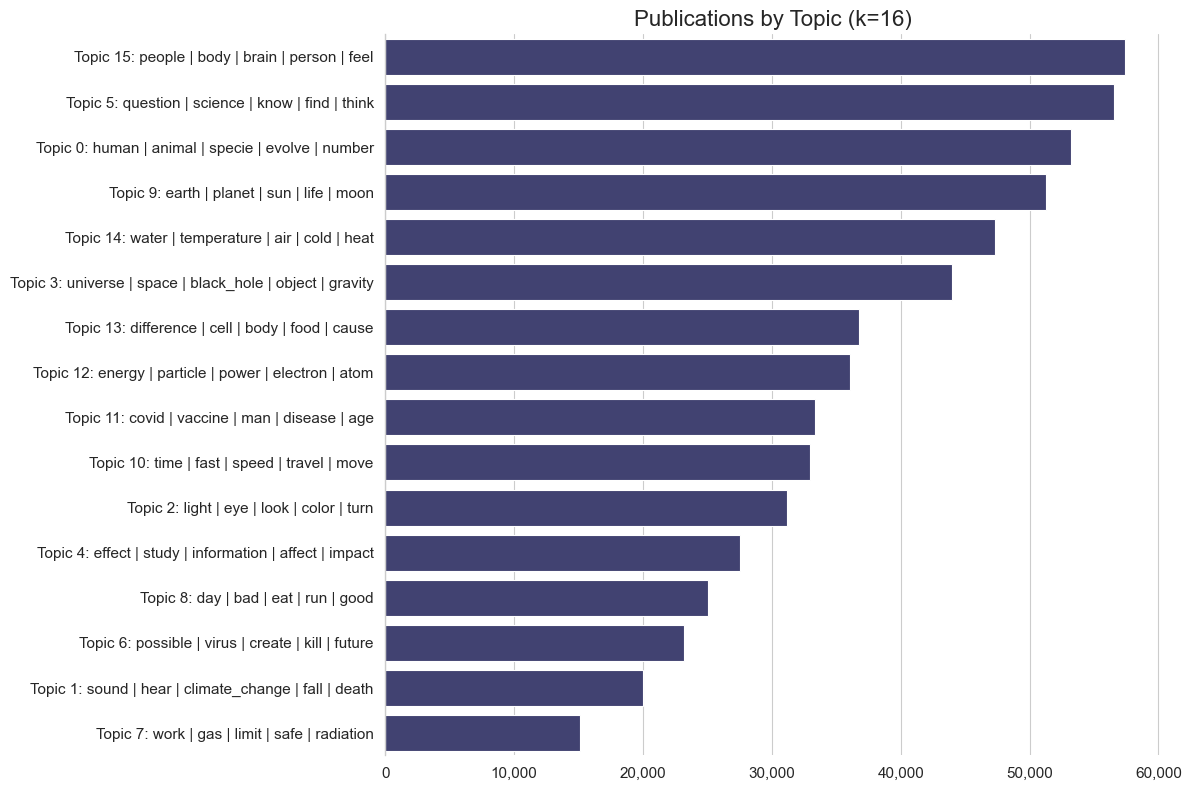

In [31]:
words = vectorizer.get_feature_names_out()

topic_labels = {}

for i, topic in enumerate(lda.components_):
    top_words = [words[j] for j in topic.argsort()[-5:][::-1]]
    topic_labels[i] = f"Topic {i}: " + " | ".join(top_words)

df["topic_label"] = df["topic"].map(topic_labels)

color = plt.colormaps["tab20b"](0)

fig, ax = plt.subplots(figsize=(12, 8))

sns.countplot(
    data=df,
    y="topic_label",
    order=df["topic_label"].value_counts().index,
    ax=ax,
    color=color
)

ax.set_title(f"Publications by Topic (k={k})", fontsize=16)
ax.set_xlabel("")
ax.set_ylabel("")

ax.tick_params(axis='y', labelsize=11)
ax.tick_params(axis='x', labelsize=11)

ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

ax.grid(axis="y", visible=False)

plt.tight_layout()
plt.savefig(f"viz/LDA_posts_per_topic_k{k}.png", dpi=300)
plt.show()

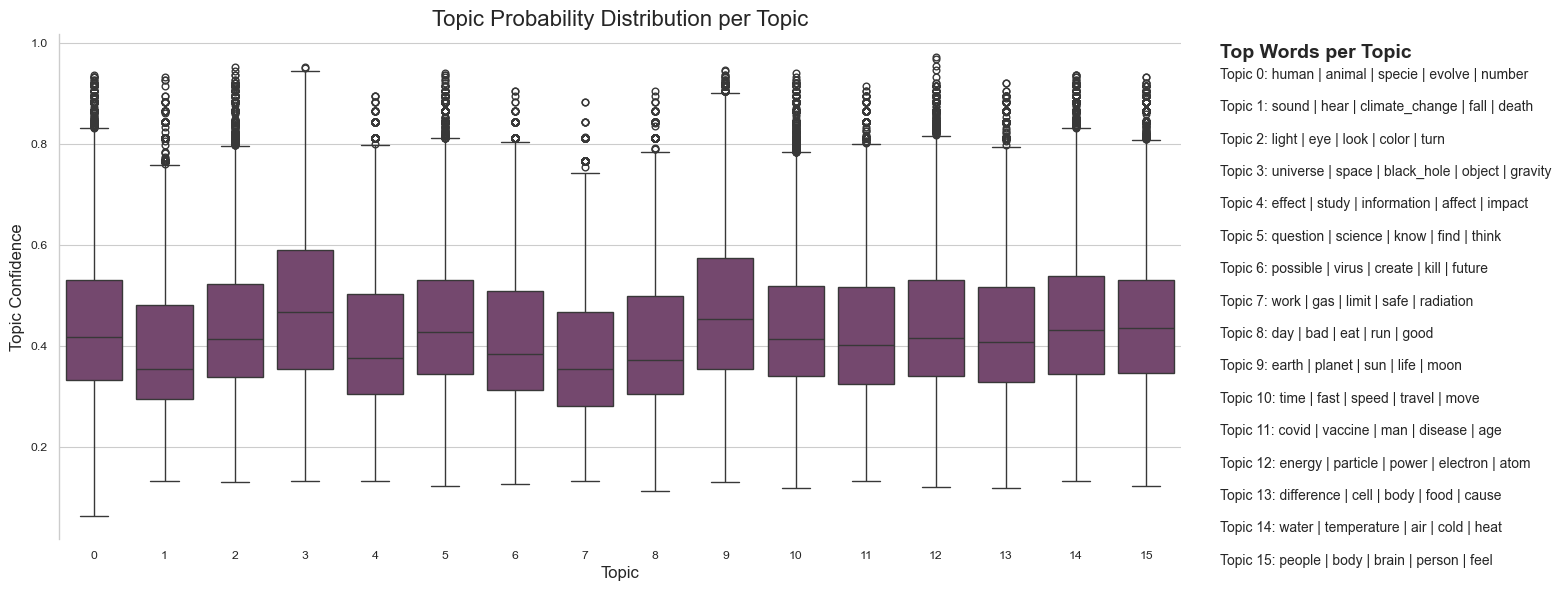

In [32]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="topic",
    y="topic_prob",
    color=plt.colormaps["tab20b"](16),
    ax=ax
)

# Titles and labels
ax.set_title("Topic Probability Distribution per Topic", fontsize=16)
ax.set_xlabel("Topic", fontsize=12)
ax.set_ylabel("Topic Confidence", fontsize=12)

# Despine plot
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# Build topic labels
words = vectorizer.get_feature_names_out()

topic_labels = {
    i: " | ".join(
        [words[j] for j in lda.components_[i].argsort()[-5:][::-1]]
    )
    for i in range(len(lda.components_))
}

# Build legend with top words
fig.text(
    1.02, 0.92,
    "Top Words per Topic",
    fontsize=14,
    fontweight="bold",
    va="top",
    ha="left"
)
legend_text = "\n\n".join(
    [f"Topic {i}: {topic_labels[i]}" for i in sorted(topic_labels)]
)
fig.text(
    1.02, 0.88,
    legend_text,
    fontsize=10,
    va="top",
    ha="left"
)

fig.subplots_adjust(right=0.7)

plt.tight_layout()
plt.savefig("viz/LDA_topic_confidence.png", dpi=300)
plt.show()